<a href="https://colab.research.google.com/github/moun-13/SmartTrafficAI/blob/main/notebooks/Smart_Traffic_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!nvidia-smi

Mon Aug 31 09:35:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   48C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# **Vérifier Python + PyTorch + CUDA**

In [3]:
import torch

print("PyTorch :", torch.__version__)
print("CUDA disponible :", torch.cuda.is_available())

if torch.cuda.is_available():
  print("GPU :",torch.cuda.get_device_name(0))

PyTorch : 2.11.0+cu128
CUDA disponible : True
GPU : Tesla T4


# **Installer YOLO**

In [4]:
!pip install -q ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.2/66.2 kB 7.3 MB/s eta 0:00:00


In [5]:
from ultralytics import YOLO
print("Ultralytics installé correctement")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
Ultralytics installé correctement


# Tester YOLO AVANT de mettre la **vidéo**


image 1/1 /content/bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 6.6ms
Speed: 114.6ms preprocess, 6.6ms inference, 40.1ms postprocess per image at shape (1, 3, 640, 480)
Results saved to /content/runs/detect/predict


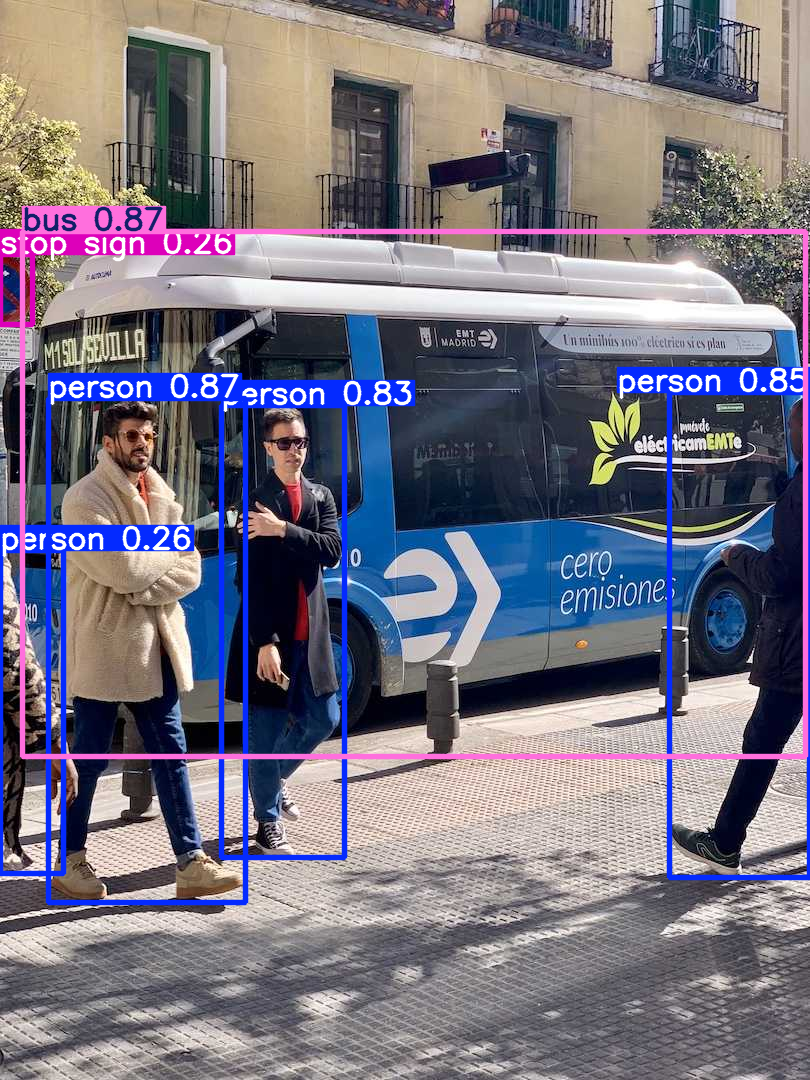

In [6]:
model = YOLO("yolov8n.pt")
results= model.predict(
    source="https://ultralytics.com/images/bus.jpg",
    conf=0.25,
    save=True
)
results[0].show()

# **Connecter Google Drive**

In [7]:
import os
import shutil
from google.colab import drive

mountpoint = "/content/drive"

# Ensure the mountpoint directory is clean before attempting to mount
# This addresses cases where 'force_remount=True' isn't enough because
# the directory isn't empty but also not an active mount.
if os.path.isdir(mountpoint):
    if not os.path.ismount(mountpoint): # Only clean if it's not a real mount
        print(f"Cleaning up non-mount directory: {mountpoint}")
        try:
            shutil.rmtree(mountpoint)
            print(f"Removed {mountpoint}")
        except OSError as e:
            print(f"Error removing directory {mountpoint}: {e}")
    else:
        print(f"'{mountpoint}' is already a mount, attempting force_remount.")

# Recreate the directory if it was removed or didn't exist, to provide a clean target
os.makedirs(mountpoint, exist_ok=True)

drive.mount(mountpoint, force_remount=True)

Mounted at /content/drive


# **Créer notre projet dans Drive**

In [8]:
import os
PROJECT_DIR="/content/drive/MyDrive/SmartTrafficAI"
os.makedirs(PROJECT_DIR,exist_ok=True)
print(PROJECT_DIR)

/content/drive/MyDrive/SmartTrafficAI


In [9]:
%cd /content/drive/MyDrive/SmartTrafficAI

/content/drive/MyDrive/SmartTrafficAI


In [10]:
print(os.getcwd())

/content/drive/MyDrive/SmartTrafficAI


# **Créer la structure**

In [11]:
folders = [
    "datasets/videos",
    "datasets/images",
    "models",
    "notebooks",
    "outputs",
    "data/raw",
    "data/processed",
    "results",
    "src"
]
for floder in folders:
  os.makedirs(floder,exist_ok=True)
print("Structure créée avec succès.")

Structure créée avec succès.


# **Ajouter ta vidéo**

In [12]:
from google.colab import files
uploaded = files.upload()

Saving traffic.mp4 to traffic.mp4


In [13]:
import shutil
import os

filename = list(uploaded.keys())[0]

destination = f"datasets/videos/{filename}"

shutil.move(filename, destination)

print("Video enregistree : ",destination)


Video enregistree :  datasets/videos/traffic.mp4


In [14]:
!ls -lh datasets/videos/

total 3.2M
-rw------- 1 root root 3.2M Aug 31 09:37 traffic.mp4


# **Afficher une image de la vidéo**

Avant de demander à YOLO de traiter toute la vidéo, on vérifie une seule frame.

In [15]:
import cv2

video_path = "datasets/videos/traffic.mp4"

cap = cv2.VideoCapture(video_path)

print("Vidéo ouverte :", cap.isOpened())
print("Frames :", int(cap.get(cv2.CAP_PROP_FRAME_COUNT)))
print("FPS :", cap.get(cv2.CAP_PROP_FPS))
print("Largeur :", int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)))
print("Hauteur :", int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT)))

cap.release()

Vidéo ouverte : True
Frames : 1800
FPS : 30.0
Largeur : 640
Hauteur : 360


# **Afficher une image de la vidéo**
Avant de demander à YOLO de traiter toute la vidéo, on vérifie une seule frame.

In [16]:
import cv2
import matplotlib.pyplot as plt

cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

print("Frame récupérée :", ret)

Frame récupérée : True


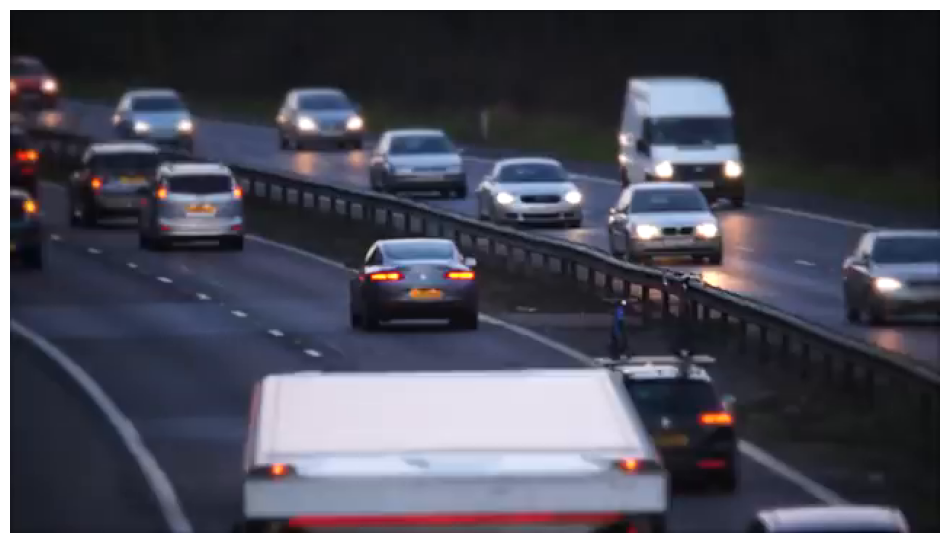

In [17]:
if ret:
  frame_rgb = cv2.cvtColor(frame,cv2.COLOR_BGR2RGB)

  plt.figure(figsize=(12, 7))
  plt.imshow(frame_rgb)
  plt.axis("off")
  plt.show()

# **YOLO sur UNE seule frame**


0: 384x640 14 cars, 1 bus, 1 truck, 130.4ms
Speed: 1.9ms preprocess, 130.4ms inference, 63.2ms postprocess per image at shape (1, 3, 384, 640)


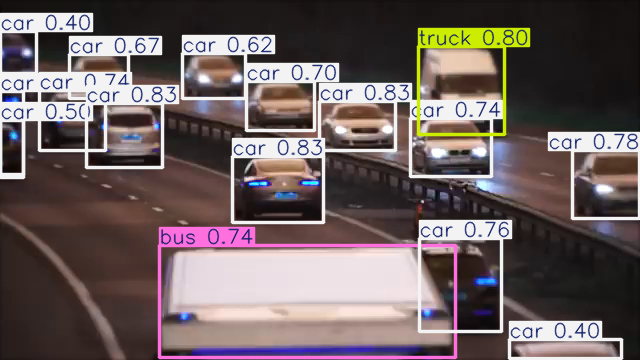

Nombre de vécule détectés : 16


In [18]:
result = model.predict(
    source=frame_rgb,
    classes=[2,3,5,7],
    conf=0.25
)
result[0].show()

print("Nombre de vécule détectés :",len(result[0].boxes))

# **YOLO sur toute la vidéo**



In [19]:
vehicle_classes = [2, 3, 5, 7]

results = model.predict(
    source=video_path,
    classes=vehicle_classes,
    conf=0.25,
    save=True
)


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1800) /content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4: 384x640 15 cars, 1 bus, 1 truck, 10.4ms
video 1/1 (frame 2/1800) /content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4: 384x640 16 cars, 1 bus, 2 trucks, 11.5ms
video 1/1 (frame 3/1800) /content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4: 384x640 16 cars, 1 bus, 1 truck, 7.3ms
video 1/1 (frame 4/1800) /content/drive/MyDrive/SmartTrafficAI/

***On va donc copier le résultat dans ton Google Drive.***

In [20]:
import os
import shutil

source_video = "/content/runs/detect/predict/traffic.avi"

destination_dir = "/content/drive/MyDrive/SmartTrafficAI/outputs/detection"

os.makedirs(destination_dir, exist_ok=True)

destination_video = os.path.join(
    destination_dir,
    "traffic_detection.avi"
)

shutil.copy2(source_video, destination_video)

print("Vidéo sauvegardée dans Google Drive :")
print(destination_video)

Vidéo sauvegardée dans Google Drive :
/content/drive/MyDrive/SmartTrafficAI/outputs/detection/traffic_detection.avi


In [21]:
#verifier
import os

print("Existe :", os.path.exists(destination_video))

if os.path.exists(destination_video):
    print("Taille :", round(os.path.getsize(destination_video) / (1024**2), 2), "MB")

Existe : True
Taille : 73.22 MB


In [22]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")
vehicule_classes = [2, 3, 5, 7]

tracking_results = model.track(
    source=video_path,
    classes=vehicle_classes,
    conf=0.25,
    tracker="bytetrack.yaml",
    save=True,
    project="/content/drive/MyDrive/SmartTrafficAI/outputs/tracking",
    name="traffic_tracking",
    exist_ok=True

)

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
Using Python 3.13.15 environment at: /usr
Resolved 2 packages in 249ms
Prepared 1 package in 68ms
Installed 1 package in 1ms
 + lap==0.5.13

requirements: AutoUpdate success ✅ 0.7s
WARNING ⚠️ requirements: Restart runtime or rerun command for updates to take effect


WARNING ⚠️ 
Inference results will accumulate in RAM unless `stream=True` is passed, which can cause out-of-memory errors for large
sources or long-running streams and videos. See https://docs.ultralytics.com/modes/predict for help.

Example:
    results = model(source=..., stream=True)  # generator of Results objects
    for r in results:
        boxes = r.boxes  # Boxes object for bbox outputs
        masks = r.masks  # Masks object for segment masks outputs
        probs = r.probs  # Class probabilities for classification outputs

video 1/1 (frame 1/1800) /content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4: 384x640 15

In [23]:
!find /content/drive/MyDrive/SmartTrafficAI/outputs/tracking -type f

/content/drive/MyDrive/SmartTrafficAI/outputs/tracking/traffic_tracking/traffic.avi
/content/drive/MyDrive/SmartTrafficAI/outputs/tracking/traffic_tracking_ids.mp4


# **Corriger le tracking**

In [24]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

vehicle_classes = [2, 3, 5, 7]

video_path = "/content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4"


In [25]:
import cv2
import os

output_dir = "/content/drive/MyDrive/SmartTrafficAI/outputs/tracking"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(output_dir, "traffic_tracking_ids.mp4")

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS :", fps)
print("Résolution :", width, "x", height)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

FPS : 30.0
Résolution : 640 x 360


In [26]:
while True:

    ret, frame = cap.read()

    if not ret:
        break

    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=vehicle_classes,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    # Image avec les détections + IDs
    annotated_frame = result.plot()

    writer.write(annotated_frame)

cap.release()
writer.release()

print("Tracking terminé.")
print("Résultat :", output_path)

Tracking terminé.
Résultat : /content/drive/MyDrive/SmartTrafficAI/outputs/tracking/traffic_tracking_ids.mp4


# **Vérifier si YOLO réellement attribué des IDs**

In [27]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

results = model.track(
    frame,
    persist=True,
    tracker="bytetrack.yaml",
    classes=vehicle_classes,
    conf=0.25,
    verbose=False
)

result = results[0]

print("Nombre de véhicules :", len(result.boxes))
print("IDs :", result.boxes.id)

Nombre de véhicules : 9
IDs : tensor([1778., 1165., 1793., 1813., 1823., 1829., 1833., 1840., 1847.], device='cuda:0')


IDs : tensor([1778., 1165., 1793., 1813., 1823., 1829., 1833., 1840., 1847.], device='cuda:0')


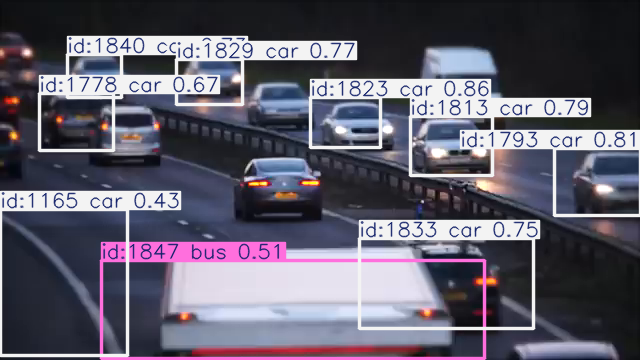

In [28]:
print("IDs :", result.boxes.id)
result.show()

# **9.1 — Préparer les chemins**

In [29]:
import cv2
import os
from collections import defaultdict
from ultralytics import YOLO

# Modèle
model = YOLO("yolov8n.pt")

# Vidéo originale
video_path = "/content/drive/MyDrive/SmartTrafficAI/datasets/videos/traffic.mp4"

#dossier de sortie
output_dir = "/content/drive/MyDrive/SmartTrafficAI/outputs/counting"
os.makedirs(output_dir,exist_ok=True)

output_path = os.path.join(
    output_dir,
    "traffic_counting.mp4"
)

#Classes véhucule les Coco
vehicule_classes = [2, 3, 5, 7]

print("Video : ", os.path.exists(video_path))
print("Sortie : ",output_path)




Video :  True
Sortie :  /content/drive/MyDrive/SmartTrafficAI/outputs/counting/traffic_counting.mp4


# 9.2 — Lire les dimensions de la vidéo

In [30]:
cap = cv2.VideoCapture(video_path)

fps    = cap.get(cv2.CAP_PROP_FPS)
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

cap.release()

print("FPS :", fps)
print("Résolution :", width, "x", height)
print("Frames :", total_frames)

FPS : 30.0
Résolution : 640 x 360
Frames : 1800


# **9.3 Creer la ligne de comptage**

In [31]:
line_y = int(height * 0.60)

print("Ligne de comptage Y =", line_y)

Ligne de comptage Y = 216


# **Nous allons garder la position précédente de chaque véhicule :**

In [32]:
previsious_positions = {}

# IDs déjà comptés
counted_ids = set()

# Compteurs par type
vehicle_name = {
    2:"Car",
    3:"Motorcycle",
    5:"cycle",
    7:"Truck"
}

# **9.5 — Lancer le comptage**

In [33]:
# ==========================================
# PHASE 9.5 — VEHICLE COUNTING
# ==========================================

from collections import defaultdict
import cv2
import os
from ultralytics import YOLO

# Nouveau modèle propre
model = YOLO("yolov8n.pt")

# Classes véhicules
vehicle_classes = [2, 3, 5, 7]

class_names = {
    2: "Car",
    3: "Motorcycle",
    5: "Bus",
    7: "Truck"
}

# Réinitialisation
previous_positions = {}
counted_ids = set()
vehicle_counts = defaultdict(int)

# Vidéo
cap = cv2.VideoCapture(video_path)

# Informations vidéo
fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Ligne de comptage
line_y = int(height * 0.60)

# Sortie
output_dir = "/content/drive/MyDrive/SmartTrafficAI/outputs/counting"
os.makedirs(output_dir, exist_ok=True)

output_path = os.path.join(
    output_dir,
    "traffic_counting.mp4"
)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

frame_number = 0

print("Début du comptage...")
print("Ligne :", line_y)

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    # Tracking
    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=vehicle_classes,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    annotated_frame = frame.copy()

    # ==========================================
    # LIGNE DE COMPTAGE
    # ==========================================

    cv2.line(
        annotated_frame,
        (0, line_y),
        (width, line_y),
        (0, 255, 255),
        3
    )

    cv2.putText(
        annotated_frame,
        "COUNTING LINE",
        (20, line_y - 15),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (0, 255, 255),
        2
    )

    # ==========================================
    # VEHICULES
    # ==========================================

    if (
        result.boxes is not None
        and result.boxes.id is not None
    ):

        boxes = result.boxes.xyxy.cpu().numpy()

        ids = (
            result.boxes.id
            .cpu()
            .numpy()
            .astype(int)
        )

        classes = (
            result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        for box, track_id, class_id in zip(
            boxes,
            ids,
            classes
        ):

            x1, y1, x2, y2 = map(int, box)

            # Centre du véhicule
            center_x = int((x1 + x2) / 2)
            center_y = int((y1 + y2) / 2)

            class_name = class_names.get(
                class_id,
                "Vehicle"
            )

            # ==================================
            # POSITION PRECEDENTE
            # ==================================

            previous_y = previous_positions.get(
                track_id
            )

            # ==================================
            # DETECTION DU FRANCHISSEMENT
            # ==================================

            if previous_y is not None:

                crossed_down = (
                    previous_y < line_y
                    and center_y >= line_y
                )

                crossed_up = (
                    previous_y > line_y
                    and center_y <= line_y
                )

                crossed = (
                    crossed_down
                    or crossed_up
                )

                if (
                    crossed
                    and track_id not in counted_ids
                ):

                    counted_ids.add(track_id)

                    vehicle_counts[class_id] += 1

                    print(
                        f"Vehicle ID {track_id} "
                        f"→ {class_name} "
                        f"COMPTÉ"
                    )

            # Mise à jour position
            previous_positions[track_id] = center_y

            # ==================================
            # BOUNDING BOX
            # ==================================

            cv2.rectangle(
                annotated_frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # ==================================
            # LABEL
            # ==================================

            label = (
                f"{class_name} ID:{track_id}"
            )

            cv2.putText(
                annotated_frame,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.6,
                (0, 255, 0),
                2
            )

            # Centre
            cv2.circle(
                annotated_frame,
                (center_x, center_y),
                5,
                (0, 0, 255),
                -1
            )

    # ==========================================
    # STATISTIQUES
    # ==========================================

    y_text = 35

    for class_id in vehicle_classes:

        class_name = class_names[class_id]

        count = vehicle_counts[class_id]

        text = f"{class_name}: {count}"

        cv2.putText(
            annotated_frame,
            text,
            (20, y_text),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (255, 255, 255),
            2
        )

        y_text += 30

    total = sum(vehicle_counts.values())

    cv2.putText(
        annotated_frame,
        f"TOTAL: {total}",
        (20, y_text + 10),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    # ==========================================
    # SAUVEGARDE FRAME
    # ==========================================

    writer.write(annotated_frame)

# ==========================================
# FIN
# ==========================================

cap.release()
writer.release()

print()
print("===================================")
print("COMPTAGE TERMINE")
print("===================================")

print("Cars        :", vehicle_counts[2])
print("Motorcycles :", vehicle_counts[3])
print("Buses       :", vehicle_counts[5])
print("Trucks      :", vehicle_counts[7])

print(
    "TOTAL       :",
    sum(vehicle_counts.values())
)

print()
print("Vidéo :", output_path)


Début du comptage...
Ligne : 216
Vehicle ID 45 → Car COMPTÉ
Vehicle ID 26 → Car COMPTÉ
Vehicle ID 38 → Truck COMPTÉ
Vehicle ID 43 → Car COMPTÉ
Vehicle ID 59 → Car COMPTÉ
Vehicle ID 92 → Car COMPTÉ
Vehicle ID 80 → Car COMPTÉ
Vehicle ID 109 → Car COMPTÉ
Vehicle ID 113 → Car COMPTÉ
Vehicle ID 148 → Truck COMPTÉ
Vehicle ID 159 → Truck COMPTÉ
Vehicle ID 158 → Car COMPTÉ
Vehicle ID 185 → Car COMPTÉ
Vehicle ID 195 → Car COMPTÉ
Vehicle ID 232 → Car COMPTÉ
Vehicle ID 237 → Car COMPTÉ
Vehicle ID 283 → Truck COMPTÉ
Vehicle ID 280 → Car COMPTÉ
Vehicle ID 287 → Car COMPTÉ
Vehicle ID 305 → Car COMPTÉ
Vehicle ID 291 → Car COMPTÉ
Vehicle ID 312 → Car COMPTÉ
Vehicle ID 292 → Car COMPTÉ
Vehicle ID 314 → Car COMPTÉ
Vehicle ID 315 → Car COMPTÉ
Vehicle ID 361 → Car COMPTÉ
Vehicle ID 353 → Car COMPTÉ
Vehicle ID 375 → Car COMPTÉ
Vehicle ID 406 → Truck COMPTÉ
Vehicle ID 382 → Car COMPTÉ
Vehicle ID 409 → Car COMPTÉ
Vehicle ID 412 → Car COMPTÉ
Vehicle ID 422 → Car COMPTÉ
Vehicle ID 459 → Car COMPTÉ
Vehicle ID 4

# **SPEED** **ESTIMATION**

In [34]:
# — SPEED ESTIMATION

from ultralytics import YOLO
import cv2
import os
import math

# CONFIGURATION
model = YOLO("yolov8n.pt")

vehicle_classes = [2, 3, 5, 7]

class_names = {
    2: "Car",
    3: "Motorcycle",
    5: "Bus",
    7: "Truck"
}

# Calibration provisoire
PIXELS_PER_METER = 8.0

# Vitesse maximale raisonnable
MAX_SPEED = 150

# VIDEO

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

print("FPS :", fps)
print("Resolution :", width, "x", height)

# OUTPUT

output_dir = (
    "/content/drive/MyDrive/"
    "SmartTrafficAI/outputs/speed"
)

os.makedirs(output_dir, exist_ok=True)

speed_output = os.path.join(
    output_dir,
    "traffic_speed.mp4"
)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

writer = cv2.VideoWriter(
    speed_output,
    fourcc,
    fps,
    (width, height)
)

# TRACKING DATA

previous_positions = {}
previous_frames = {}

vehicle_speeds = {}

frame_number = 0

# PROCESSING

while True:

    ret, frame = cap.read()

    if not ret:
        break

    frame_number += 1

    results = model.track(
        frame,
        persist=True,
        tracker="bytetrack.yaml",
        classes=vehicle_classes,
        conf=0.25,
        verbose=False
    )

    result = results[0]

    annotated_frame = frame.copy()

    if (
        result.boxes is not None
        and result.boxes.id is not None
    ):

        boxes = result.boxes.xyxy.cpu().numpy()

        ids = (
            result.boxes.id
            .cpu()
            .numpy()
            .astype(int)
        )

        classes = (
            result.boxes.cls
            .cpu()
            .numpy()
            .astype(int)
        )

        for box, track_id, class_id in zip(
            boxes,
            ids,
            classes
        ):

            x1, y1, x2, y2 = map(
                int,
                box
            )

            # Centre du véhicule
            center_x = (x1 + x2) / 2
            center_y = (y1 + y2) / 2

            current_position = (
                center_x,
                center_y
            )

            # CALCUL VITESSE

            if track_id in previous_positions:

                previous_position = (
                    previous_positions[
                        track_id
                    ]
                )

                previous_frame = (
                    previous_frames[
                        track_id
                    ]
                )

                # Distance en pixels
                dx = (
                    center_x
                    - previous_position[0]
                )

                dy = (
                    center_y
                    - previous_position[1]
                )

                distance_pixels = math.sqrt(
                    dx**2 + dy**2
                )

                # Temps en secondes
                frame_difference = (
                    frame_number
                    - previous_frame
                )

                time_seconds = (
                    frame_difference / fps
                )

                if time_seconds > 0:

                    # Distance en mètres
                    distance_meters = (
                        distance_pixels
                        / PIXELS_PER_METER
                    )

                    # m/s
                    speed_ms = (
                        distance_meters
                        / time_seconds
                    )

                    # km/h
                    speed_kmh = (
                        speed_ms * 3.6
                    )

                    # Filtrage
                    if (
                        0
                        <= speed_kmh
                        <= MAX_SPEED
                    ):

                        vehicle_speeds[
                            track_id
                        ] = speed_kmh

            # Sauvegarde position
            previous_positions[
                track_id
            ] = current_position

            previous_frames[
                track_id
            ] = frame_number

            # AFFICHAGE

            class_name = class_names.get(
                class_id,
                "Vehicle"
            )

            speed = vehicle_speeds.get(
                track_id,
                0
            )

            # Bounding box
            cv2.rectangle(
                annotated_frame,
                (x1, y1),
                (x2, y2),
                (0, 255, 0),
                2
            )

            # Label
            label = (
                f"{class_name} "
                f"ID:{track_id} "
                f"{speed:.1f} km/h"
            )

            cv2.putText(
                annotated_frame,
                label,
                (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX,
                0.55,
                (0, 255, 0),
                2
            )

            # Centre
            cv2.circle(
                annotated_frame,
                (
                    int(center_x),
                    int(center_y)
                ),
                4,
                (0, 0, 255),
                -1
            )

    # WRITE FRAME

    writer.write(
        annotated_frame
    )

cap.release()
writer.release()

print()
print("================================")
print("SPEED ESTIMATION TERMINEE")
print("================================")
print("Véhicules suivis :", len(vehicle_speeds))
print("Vidéo :", speed_output)

FPS : 30.0
Resolution : 640 x 360

SPEED ESTIMATION TERMINEE
Véhicules suivis : 399
Vidéo : /content/drive/MyDrive/SmartTrafficAI/outputs/speed/traffic_speed.mp4


In [35]:
%whos

Variable               Type            Data/Info
------------------------------------------------
MAX_SPEED              int             150
PIXELS_PER_METER       float           8.0
PROJECT_DIR            str             /content/drive/MyDrive/SmartTrafficAI
YOLO                   type            <class 'ultralytics.models.yolo.model.YOLO'>
annotated_frame        ndarray         360x640x3: 691200 elems, type `uint8`, 691200 bytes (675.0 kb)
box                    ndarray         4: 4 elems, type `float32`, 16 bytes
boxes                  ndarray         19x4: 76 elems, type `float32`, 304 bytes
cap                    VideoCapture    < cv2.VideoCapture 0x7f94afb965f0>
center_x               float           12.5
center_y               float           101.5
class_id               int64           2
class_name             str             Car
class_names            dict            n=4
classes                ndarray         19: 19 elems, type `int64`, 152 bytes
count                  int   

# **Phase 11 — Traffic Analytics**

**11.1 — Créer les statistiques**

In [36]:
import pandas as pd

traffic_data = {
    "Cars": vehicle_counts.get(2, 0),
    "Motorcycles": vehicle_counts.get(3, 0),
    "Buses": vehicle_counts.get(5, 0),
    "Trucks": vehicle_counts.get(7, 0)
}

df_traffic = pd.DataFrame([traffic_data])

df_traffic["Total"] = (
    df_traffic["Cars"]
    + df_traffic["Motorcycles"]
    + df_traffic["Buses"]
    + df_traffic["Trucks"]
)

df_traffic

,Cars,Motorcycles,Buses,Trucks,Total
0,90,2,1,16,109


**11.2 — Affichage propre**

In [37]:
print("=" *40)
print("Trafic analytics")
print("=" *40)

print(f"Cars         : {vehicle_counts.get(2, 0)}")
print(f"Motorcycles  : {vehicle_counts.get(3, 0)}")
print(f"Buses        : {vehicle_counts.get(5, 0)}")
print(f"Trucks       : {vehicle_counts.get(7, 0)}")


print("="*40)
print(f"Total   :{df_traffic['Total'].iloc[0]}")


Trafic analytics
Cars         : 90
Motorcycles  : 2
Buses        : 1
Trucks       : 16
Total   :109


**11.3 — Graphique**

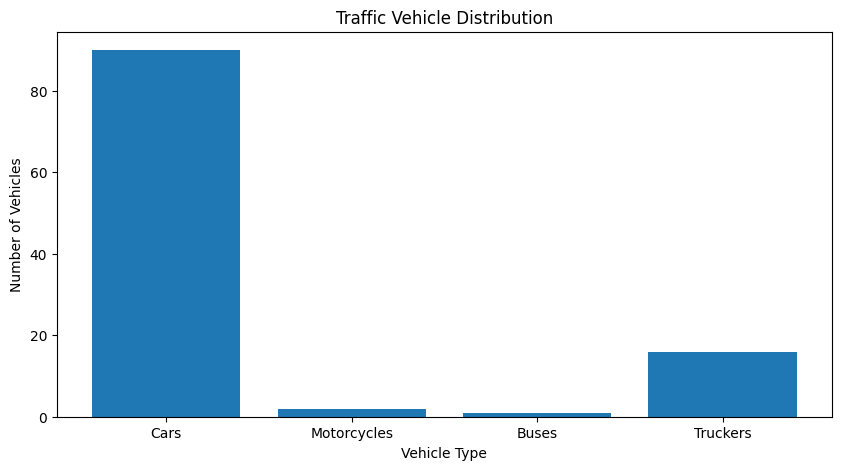

In [38]:
import matplotlib.pyplot as plt

categories = [
    "Cars",
    "Motorcycles",
    "Buses",
    "Truckers"
]

values = [
    vehicle_counts.get(2,0),
    vehicle_counts.get(3,0),
    vehicle_counts.get(5,0),
    vehicle_counts.get(7,0)
]

plt.figure(figsize=(10,5))
plt.bar(categories, values)

plt.title("Traffic Vehicle Distribution")
plt.xlabel("Vehicle Type")
plt.ylabel("Number of Vehicles")

plt.show()


**11.4 — Pourcentage de chaque type**

In [39]:
total = df_traffic["Total"].iloc[0]

df_traffic["Cars_%"] = df_traffic["Cars"] /total * 100
df_traffic["Motorcycles_%"] = df_traffic["Motorcycles"] / total * 100
df_traffic["Buses_%"] = df_traffic["Buses"] / total * 100
df_traffic["Trucks_%"] = df_traffic["Trucks"] / total * 100

df_traffic

,Cars,Motorcycles,Buses,Trucks,Total,Cars_%,Motorcycles_%,Buses_%,Trucks_%
0,90,2,1,16,109,82.568807,1.834862,0.917431,14.678899


# **Phase 12 — Speed Analytics**

**12.1 — Transformer les vitesses en DataFrame**

In [40]:
import pandas as pd
import numpy as np

speed_data = []

for track_id, speed in vehicle_speeds.items():
    speed_data.append({
        "vehicle_id": int(track_id),
        "speed_kmh": float(speed)
    })

df_speed = pd.DataFrame(speed_data)

print("Nombre de véhicules avec vitesse :", len(df_speed))

df_speed.head()

Nombre de véhicules avec vitesse : 399


,vehicle_id,speed_kmh
0,1,52.719185
1,2,27.830963
2,3,47.729708
3,4,42.690748
4,5,54.420240


**12.2 — Statistiques de vitesse**

In [41]:
print("=" * 45)
print("          SPEED ANALYTICS")
print("=" * 45)

print(f"Vitesse moyenne : {df_speed['speed_kmh'].mean():.2f} km/h")
print(f"Vitesse maximale : {df_speed['speed_kmh'].max():.2f} km/h")
print(f"Vitesse minimale : {df_speed['speed_kmh'].min():.2f} km/h")
print(f"Médiane : {df_speed['speed_kmh'].median():.2f} km/h")

          SPEED ANALYTICS
Vitesse moyenne : 51.39 km/h
Vitesse maximale : 143.19 km/h
Vitesse minimale : 0.00 km/h
Médiane : 47.73 km/h


**12.3 —  Détecter les excès de vitesse**

In [42]:
MAX_SPEED = 150

df_speed["overspeed"] = df_speed["speed_kmh"] > MAX_SPEED

overspeed_vehicles = df_speed[df_speed["overspeed"] == True]

print("Limite :", MAX_SPEED, "km/h")
print("Véhicules en excès de vitesse :", len(overspeed_vehicles))

overspeed_vehicles

Limite : 150 km/h
Véhicules en excès de vitesse : 0


,vehicle_id,speed_kmh,overspeed


**12.4 — Distribution des vitesses**

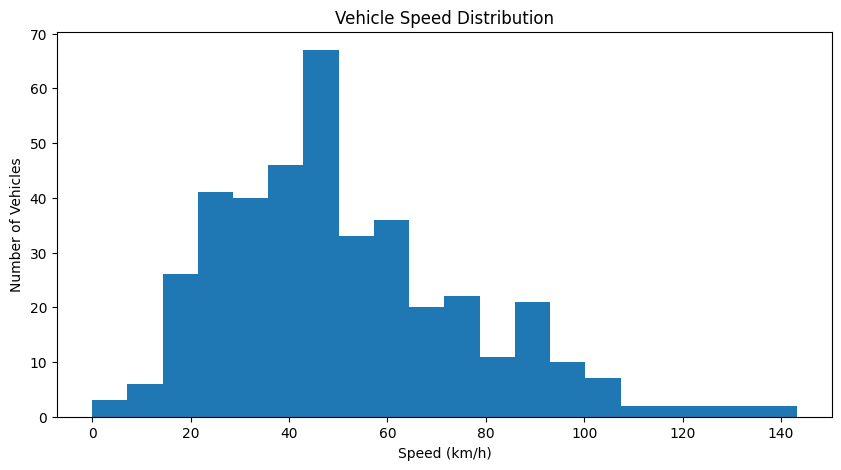

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.hist(df_speed["speed_kmh"], bins=20)

plt.title("Vehicle Speed Distribution")
plt.xlabel("Speed (km/h)")
plt.ylabel("Number of Vehicles")

plt.show()

**12.5 — Les véhicules les plus rapides**

In [44]:
df_speed.sort_values(
    by="speed_kmh",
    ascending=False
).head(10)

,vehicle_id,speed_kmh,overspeed
91,408,143.189123,False
82,371,136.510302,False
87,383,135.673321,False
298,1421,129.838842,False
348,1680,128.294400,False
14,15,126.100406,False
292,1400,115.541389,False
280,1355,114.750000,False
308,1475,109.882039,False
359,1732,108.210732,False


**Phase 13 — Créer le dataset Traffic Events**  

In [45]:
# PHASE 13 — TRAFFIC DATASET
import pandas as pd
import os

traffic_events = []
print("Préparation du dataset...")

Préparation du dataset...


In [46]:
print(type(tracking_results))
print("Nombre de frames : ", len(tracking_results))

print("\nPremier élément :")
print(tracking_results[0])

<class 'list'>
Nombre de frames :  1800

Premier élément :
ultralytics.engine.results.Results object with attributes:

boxes: ultralytics.engine.results.Boxes object
depth: None
keypoints: None
masks: None
names: {0: 'person', 1: 'bicycle', 2: 'car', 3: 'motorcycle', 4: 'airplane', 5: 'bus', 6: 'train', 7: 'truck', 8: 'boat', 9: 'traffic light', 10: 'fire hydrant', 11: 'stop sign', 12: 'parking meter', 13: 'bench', 14: 'bird', 15: 'cat', 16: 'dog', 17: 'horse', 18: 'sheep', 19: 'cow', 20: 'elephant', 21: 'bear', 22: 'zebra', 23: 'giraffe', 24: 'backpack', 25: 'umbrella', 26: 'handbag', 27: 'tie', 28: 'suitcase', 29: 'frisbee', 30: 'skis', 31: 'snowboard', 32: 'sports ball', 33: 'kite', 34: 'baseball bat', 35: 'baseball glove', 36: 'skateboard', 37: 'surfboard', 38: 'tennis racket', 39: 'bottle', 40: 'wine glass', 41: 'cup', 42: 'fork', 43: 'knife', 44: 'spoon', 45: 'bowl', 46: 'banana', 47: 'apple', 48: 'sandwich', 49: 'orange', 50: 'broccoli', 51: 'carrot', 52: 'hot dog', 53: 'pizza',

**13.1 — Créer le DataFrame**

In [47]:
import pandas as pd

tracking_data = []

for frame_number, frame_results in enumerate(tracking_results):

    if frame_results.boxes is None:
        continue

    boxes = frame_results.boxes

    if boxes.id is None:
        continue

    ids = boxes.id.cpu().numpy()
    classes = boxes.cls.cpu().numpy()
    xyxy = boxes.xyxy.cpu().numpy()

    for track_id, class_id, box in zip(ids, classes, xyxy):

        x1, y1, x2, y2 = box

        center_x = (x1 + x2) / 2
        center_y = (y1 + y2) / 2

        tracking_data.append({
            "frame": frame_number,
            "track_id": int(track_id),
            "class_id": int(class_id),
            "center_x": center_x,
            "center_y": center_y
        })

df_tracking = pd.DataFrame(tracking_data)

print("Nombre de détections :", len(df_tracking))
print("Nombre de véhicules uniques :", df_tracking["track_id"].nunique())

df_tracking.head()

Nombre de détections : 22046
Nombre de véhicules uniques : 456


,frame,track_id,class_id,center_x,center_y
0,0,1,2,357.337280,126.687012
1,0,2,2,278.261719,189.287201
2,0,3,2,280.553772,106.183052
3,0,4,7,461.304810,90.398537
4,0,5,2,606.029907,184.306427


In [48]:
#resultas

print(df_tracking.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22046 entries, 0 to 22045
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   frame     22046 non-null  int64  
 1   track_id  22046 non-null  int64  
 2   class_id  22046 non-null  int64  
 3   center_x  22046 non-null  float32
 4   center_y  22046 non-null  float32
dtypes: float32(2), int64(3)
memory usage: 689.1 KB
None


In [49]:
print(df_tracking["class_id"].value_counts())

class_id
2    19323
7     2192
5      389
3      142
Name: count, dtype: int64


In [50]:
df_tracking.head(10)

,frame,track_id,class_id,center_x,center_y
0,0,1,2,357.337280,126.687012
1,0,2,2,278.261719,189.287201
2,0,3,2,280.553772,106.183052
3,0,4,7,461.304810,90.398537
4,0,5,2,606.029907,184.306427
5,0,6,2,124.839478,135.725983
6,0,7,2,450.442993,147.504547
7,0,8,2,213.834045,75.983536
8,0,9,2,459.493317,285.644226
9,0,10,2,98.804321,76.936836


**13.3 — Ajouter le nom du véhicule**

In [51]:
df_tracking["vehicle"] = df_tracking["class_id"].map(class_names)

df_tracking.head()

,frame,track_id,class_id,center_x,center_y,vehicle
0,0,1,2,357.337280,126.687012,Car
1,0,2,2,278.261719,189.287201,Car
2,0,3,2,280.553772,106.183052,Car
3,0,4,7,461.304810,90.398537,Truck
4,0,5,2,606.029907,184.306427,Car


In [52]:
csv_path = f"{PROJECT_DIR}/outputs/tracking_results.csv"

df_tracking.to_csv(csv_path, index=False)

print("Dataset sauvegardé :")
print(csv_path)



Dataset sauvegardé :
/content/drive/MyDrive/SmartTrafficAI/outputs/tracking_results.csv


In [53]:
!ls -lh "{PROJECT_DIR}/outputs/"


total 753K
drwx------ 2 root root 4.0K Aug 31 09:39 counting
drwx------ 2 root root 4.0K Aug 31 09:38 detection
drwx------ 2 root root 4.0K Aug 31 09:40 speed
drwx------ 3 root root 4.0K Aug 31 09:39 tracking
-rw------- 1 root root 737K Aug 31 09:40 tracking_results.csv


# **Étape 14 — Statistiques des véhicules**

In [54]:
vehicle_statistics = (
    df_tracking
    .groupby("vehicle")["track_id"]
    .nunique()
    .sort_values(ascending=False)
)

print("======================================")
print("STATISTIQUES DES VÉHICULES")
print("======================================")

print(vehicle_statistics)

STATISTIQUES DES VÉHICULES
vehicle
Car           385
Truck         133
Bus            38
Motorcycle      5
Name: track_id, dtype: int64


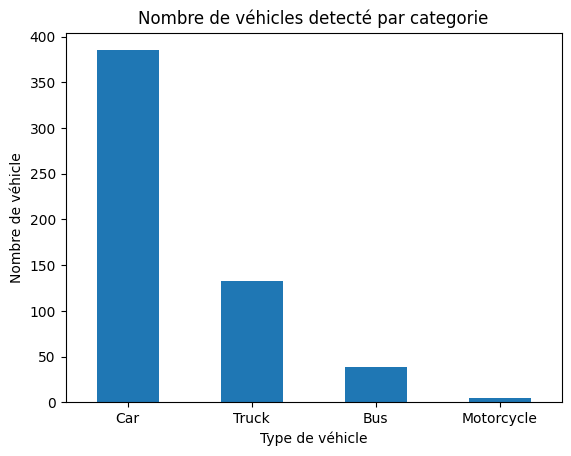

In [55]:
import matplotlib.pyplot as plt
vehicle_statistics.plot(kind="bar")

plt.title("Nombre de véhicles detecté par categorie")
plt.xlabel("Type de véhicle")
plt.ylabel("Nombre de véhicle")
plt.xticks(rotation=0)
plt.show()

# **Phase 15 — Analyse de la vitesse de chaque véhicule**





In [56]:

# PHASE 15 — ANALYSE DE LA VITESSE

print("======================================")
print("VITESSE DE CHAQUE VÉHICULE")
print("======================================")

print(df_speed)

VITESSE DE CHAQUE VÉHICULE
     vehicle_id  speed_kmh  overspeed
0             1  52.719185      False
1             2  27.830963      False
2             3  47.729708      False
3             4  42.690748      False
4             5  54.420240      False
..          ...        ...        ...
394        1840  81.280763      False
395        1847  52.719185      False
396        1850  88.782388      False
397        1836  24.337471      False
398        1852  87.750000      False

[399 rows x 3 columns]


In [57]:
# Les 10 véhicules les plus rapides

top_10 = df_speed.sort_values(
    by="speed_kmh",
    ascending=False
).head(10)

print("======================================")
print("TOP 10 DES VÉHICULES LES PLUS RAPIDES")
print("======================================")

print(top_10)

TOP 10 DES VÉHICULES LES PLUS RAPIDES
     vehicle_id   speed_kmh  overspeed
91          408  143.189123      False
82          371  136.510302      False
87          383  135.673321      False
298        1421  129.838842      False
348        1680  128.294400      False
14           15  126.100406      False
292        1400  115.541389      False
280        1355  114.750000      False
308        1475  109.882039      False
359        1732  108.210732      False


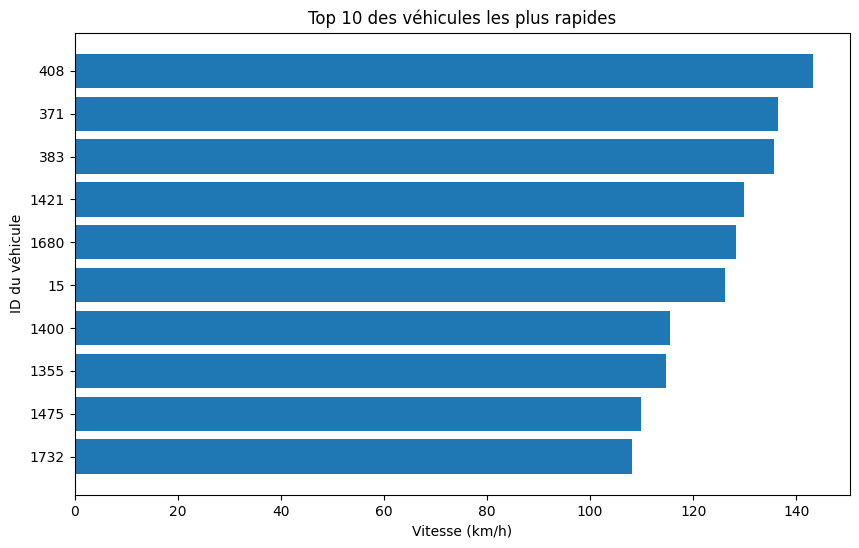

In [58]:
import matplotlib.pyplot as plt

top_10_plot = top_10.sort_values("speed_kmh")

plt.figure(figsize=(10, 6))

plt.barh(
    top_10_plot["vehicle_id"].astype(str),
    top_10_plot["speed_kmh"]
)

plt.title("Top 10 des véhicules les plus rapides")
plt.xlabel("Vitesse (km/h)")
plt.ylabel("ID du véhicule")

plt.show()

# **Phase 16 — Détection des excès de vitesse**

In [59]:
# PHASE 16 — EXCÈS DE VITESSE

SPEED_LIMIT = 50

df_speed["overspeed"] = df_speed["speed_kmh"] > SPEED_LIMIT

print("Limite de vitesse :", SPEED_LIMIT, "km/h")

Limite de vitesse : 50 km/h


In [60]:
overspeed_vehicles = df_speed[
    df_speed["overspeed"] == True
]

print("Nombre de véhicules en excès de vitesse :",
      len(overspeed_vehicles))

print("\nVéhicules concernés :")
print(overspeed_vehicles)

Nombre de véhicules en excès de vitesse : 170

Véhicules concernés :
     vehicle_id   speed_kmh  overspeed
0             1   52.719185       True
4             5   54.420240       True
8             9   57.275649       True
14           15  126.100406       True
16           26   58.672822       True
..          ...         ...        ...
393        1833   88.009232       True
394        1840   81.280763       True
395        1847   52.719185       True
396        1850   88.782388       True
398        1852   87.750000       True

[170 rows x 3 columns]


In [61]:
overspeed_vehicles.sort_values(
    by="speed_kmh",
    ascending=False
)

,vehicle_id,speed_kmh,overspeed
91,408,143.189123,True
82,371,136.510302,True
87,383,135.673321,True
298,1421,129.838842,True
348,1680,128.294400,True
...,...,...,...
221,1067,51.406468,True
200,982,51.406468,True
309,1476,51.406468,True
346,1667,51.406468,True
